# Anomaly Detection for Energy Analytics - NSP Dataset

## Objective
Implement multiple anomaly detection methods and export results for Tableau dashboard.

Required output: `anomaly_results.csv` with columns:
- timestamp
- region
- consumption_kwh
- anomaly_flag
- anomaly_type
- anomaly_method

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Paths
ROOT_DIR = Path.cwd().parent
DATA_DIR = ROOT_DIR / "data"
OUTPUT_DIR = ROOT_DIR / "output"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Helper function
def save_and_show_plot(fig, filename):
    output_path = OUTPUT_DIR / filename
    fig.savefig(output_path, dpi=300, bbox_inches='tight')
    print(f"Saved: {output_path}")
    plt.show()

print("Setup complete!")

Setup complete!


In [5]:
# Load engineered features
df = pd.read_csv(OUTPUT_DIR / 'engineered_features.csv', parse_dates=['timestamp'])

# Reconstruct region column if needed
if 'region' not in df.columns:
    region_cols = [col for col in df.columns if col.startswith('region_')]
    df['region'] = df[region_cols].idxmax(axis=1).str.replace('region_', '')

print(f"Dataset shape: {df.shape}")
print(f"Regions: {sorted(df['region'].unique())}")
print(f"Date range: {df['timestamp'].min()} to {df['timestamp'].max()}")

# Check existing anomaly_flag column
if 'anomaly_flag' in df.columns:
    print(f"\nExisting anomaly_flag distribution:")
    print(df['anomaly_flag'].value_counts())
    print(f"Anomaly rate: {df['anomaly_flag'].sum() / len(df) * 100:.2f}%")

df.head()

Dataset shape: (438240, 32)
Regions: ['Annapolis Valley', 'Cape Breton', 'Halifax', 'Pictou County', 'South Shore']
Date range: 2015-01-02 00:00:00 to 2024-12-31 23:00:00

Existing anomaly_flag distribution:
anomaly_flag
0    429188
1      9052
Name: count, dtype: int64
Anomaly rate: 2.07%


,timestamp,region,hour,day_of_week,month,year,week,is_weekend,season,is_holiday,...,demand_response,power_outage,anomaly_flag,anomaly_type,peak_demand_flag,consumption_kwh_lag_1h,consumption_kwh_lag_24h,rolling_mean_168h,rolling_std_24h,hdd
0,2015-01-02 00:00:00,Annapolis Valley,0,4,1,2015,1,0,Winter,0,...,0,0,0,Normal,0,125.58,125.53,205.136000,144.622016,26.8
1,2015-01-02 01:00:00,Annapolis Valley,1,4,1,2015,1,0,Winter,0,...,0,0,0,Normal,0,114.19,94.93,201.626923,144.025200,9.5
2,2015-01-02 02:00:00,Annapolis Valley,2,4,1,2015,1,0,Winter,0,...,0,0,0,Normal,0,113.90,103.48,197.735926,144.252549,15.8
3,2015-01-02 03:00:00,Annapolis Valley,3,4,1,2015,1,0,Winter,0,...,0,0,0,Normal,0,96.57,82.12,194.675714,143.234144,19.8
4,2015-01-02 04:00:00,Annapolis Valley,4,4,1,2015,1,0,Winter,0,...,0,0,0,Normal,0,112.05,81.56,192.255172,141.819107,24.2


## Understanding Existing Anomalies

Let's analyze the pre-labeled anomalies in the dataset before implementing our own detection methods.

Existing Anomalies by Region:
                  Anomaly_Count  Total_Records  Anomaly_Rate
region                                                      
Annapolis Valley           1892          87648      2.158635
Cape Breton                1890          87648      2.156353
Halifax                    1823          87648      2.079911
Pictou County              1580          87648      1.802665
South Shore                1867          87648      2.130111
Saved: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/existing_anomalies_by_region.png


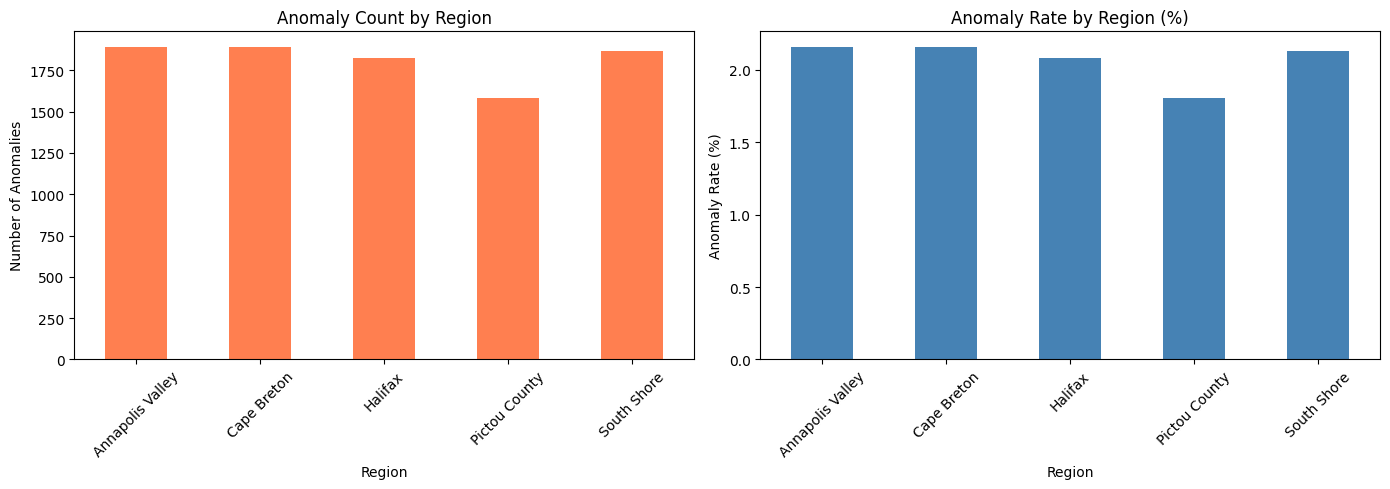

In [8]:
# Analyze existing anomalies by region
anomaly_by_region = df.groupby('region')['anomaly_flag'].agg(['sum', 'count', 'mean'])
anomaly_by_region.columns = ['Anomaly_Count', 'Total_Records', 'Anomaly_Rate']
anomaly_by_region['Anomaly_Rate'] = anomaly_by_region['Anomaly_Rate'] * 100

print("Existing Anomalies by Region:")
print(anomaly_by_region)

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of counts
anomaly_by_region['Anomaly_Count'].plot(kind='bar', ax=axes[0], color='coral')
axes[0].set_title('Anomaly Count by Region')
axes[0].set_ylabel('Number of Anomalies')
axes[0].set_xlabel('Region')
axes[0].tick_params(axis='x', rotation=45)

# Anomaly rate
anomaly_by_region['Anomaly_Rate'].plot(kind='bar', ax=axes[1], color='steelblue')
axes[1].set_title('Anomaly Rate by Region (%)')
axes[1].set_ylabel('Anomaly Rate (%)')
axes[1].set_xlabel('Region')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
save_and_show_plot(fig, 'existing_anomalies_by_region.png')

## Statistical Method 1: Z-Score Detection

Detects anomalies based on standard deviations from the mean.
- Threshold: |z-score| > 3
- Applied per region to account for regional differences

In [6]:
def detect_zscore_anomalies(df, column='consumption_kwh', threshold=3):
    """Detect anomalies using Z-score method per region"""
    df_copy = df.copy()
    df_copy['zscore_anomaly'] = 0
    
    for region in df_copy['region'].unique():
        mask = df_copy['region'] == region
        values = df_copy.loc[mask, column]
        
        # Calculate z-scores
        z_scores = np.abs(stats.zscore(values, nan_policy='omit'))
        
        # Mark anomalies
        df_copy.loc[mask, 'zscore_anomaly'] = (z_scores > threshold).astype(int)
    
    return df_copy

# Apply Z-score detection
df = detect_zscore_anomalies(df)

zscore_stats = df.groupby('region')['zscore_anomaly'].agg(['sum', 'mean'])
zscore_stats.columns = ['Anomaly_Count', 'Anomaly_Rate']
zscore_stats['Anomaly_Rate'] = zscore_stats['Anomaly_Rate'] * 100

print("Z-Score Anomaly Detection Results:")
print(zscore_stats)
print(f"\nTotal anomalies detected: {df['zscore_anomaly'].sum()} ({df['zscore_anomaly'].mean()*100:.2f}%)")

Z-Score Anomaly Detection Results:
                  Anomaly_Count  Anomaly_Rate
region                                       
Annapolis Valley            720      0.821468
Cape Breton                 692      0.789522
Halifax                     687      0.783817
Pictou County               601      0.685697
South Shore                 673      0.767844

Total anomalies detected: 3373 (0.77%)


## Statistical Method 2: IQR (Interquartile Range) Detection

Robust to outliers, uses quartile-based thresholds.
- Anomalies: values < Q1 - 1.5×IQR or > Q3 + 1.5×IQR
- Applied per region

In [7]:
def detect_iqr_anomalies(df, column='consumption_kwh', multiplier=1.5):
    """Detect anomalies using IQR method per region"""
    df_copy = df.copy()
    df_copy['iqr_anomaly'] = 0
    
    for region in df_copy['region'].unique():
        mask = df_copy['region'] == region
        values = df_copy.loc[mask, column]
        
        # Calculate IQR
        Q1 = values.quantile(0.25)
        Q3 = values.quantile(0.75)
        IQR = Q3 - Q1
        
        # Define bounds
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        # Mark anomalies
        anomalies = (values < lower_bound) | (values > upper_bound)
        df_copy.loc[mask, 'iqr_anomaly'] = anomalies.astype(int)
    
    return df_copy

# Apply IQR detection
df = detect_iqr_anomalies(df)

iqr_stats = df.groupby('region')['iqr_anomaly'].agg(['sum', 'mean'])
iqr_stats.columns = ['Anomaly_Count', 'Anomaly_Rate']
iqr_stats['Anomaly_Rate'] = iqr_stats['Anomaly_Rate'] * 100

print("IQR Anomaly Detection Results:")
print(iqr_stats)
print(f"\nTotal anomalies detected: {df['iqr_anomaly'].sum()} ({df['iqr_anomaly'].mean()*100:.2f}%)")

IQR Anomaly Detection Results:
                  Anomaly_Count  Anomaly_Rate
region                                       
Annapolis Valley           1093      1.247034
Cape Breton                1644      1.875685
Halifax                    1304      1.487769
Pictou County              1378      1.572198
South Shore                1177      1.342871

Total anomalies detected: 6596 (1.51%)


## Machine Learning Method: Isolation Forest

Uses multivariate features to detect anomalies:
- Features: consumption_kwh, lags, rolling stats, weather, time features
- Contamination rate: 0.02 (expect ~2% anomalies, matching existing labels)
- Applied per region

In [10]:
def detect_isolation_forest_anomalies(df, contamination=0.02):
    """Detect anomalies using Isolation Forest with multivariate features"""
    df_copy = df.copy()
    df_copy['isolation_forest_anomaly'] = 0
    
    # Select features for anomaly detection
    feature_cols = ['consumption_kwh', 'consumption_kwh_lag_1h', 'consumption_kwh_lag_24h',
                   'rolling_mean_168h', 'rolling_std_24h',
                   'temperature_c', 'humidity_pct', 'hour', 'day_of_week',
                   'grid_load_pct', 'renewable_pct']
    
    for region in df_copy['region'].unique():
        print(f"Training Isolation Forest for {region}...")
        mask = df_copy['region'] == region
        
        # Extract features and drop NaN
        X = df_copy.loc[mask, feature_cols].ffill().bfill()
        
        # Standardize features
        scaler = StandardScaler()
        X_scaled = scaler.fit_transform(X)
        
        # Train Isolation Forest
        iso_forest = IsolationForest(contamination=contamination, 
                                    random_state=42,
                                    n_estimators=100)
        predictions = iso_forest.fit_predict(X_scaled)
        
        # Convert predictions: -1 (anomaly) -> 1, 1 (normal) -> 0
        anomalies = (predictions == -1).astype(int)
        df_copy.loc[mask, 'isolation_forest_anomaly'] = anomalies
    
    return df_copy

# Apply Isolation Forest
df = detect_isolation_forest_anomalies(df, contamination=0.02)

iso_stats = df.groupby('region')['isolation_forest_anomaly'].agg(['sum', 'mean'])
iso_stats.columns = ['Anomaly_Count', 'Anomaly_Rate']
iso_stats['Anomaly_Rate'] = iso_stats['Anomaly_Rate'] * 100

print("\nIsolation Forest Anomaly Detection Results:")
print(iso_stats)
print(f"\nTotal anomalies detected: {df['isolation_forest_anomaly'].sum()} ({df['isolation_forest_anomaly'].mean()*100:.2f}%)")

Training Isolation Forest for Annapolis Valley...
Training Isolation Forest for Cape Breton...
Training Isolation Forest for Halifax...
Training Isolation Forest for Pictou County...
Training Isolation Forest for South Shore...

Isolation Forest Anomaly Detection Results:
                  Anomaly_Count  Anomaly_Rate
region                                       
Annapolis Valley           1753      2.000046
Cape Breton                1753      2.000046
Halifax                    1753      2.000046
Pictou County              1753      2.000046
South Shore                1753      2.000046

Total anomalies detected: 8765 (2.00%)


## Method Comparison

Comparing detection rates across all methods.


Method Comparison:
          Method  Total_Anomalies  Anomaly_Rate_%
 Existing Labels             9052        2.065535
         Z-Score             3373        0.769670
             IQR             6596        1.505111
Isolation Forest             8765        2.000046
Saved: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/anomaly_detection_comparison.png


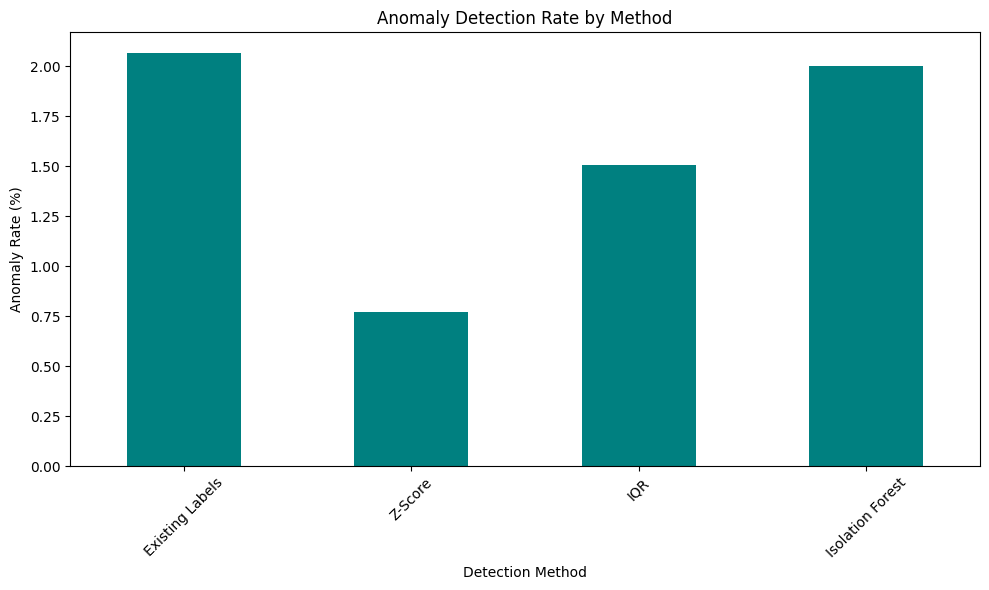

In [11]:
# Create comparison summary
comparison = pd.DataFrame({
    'Method': ['Existing Labels', 'Z-Score', 'IQR', 'Isolation Forest'],
    'Total_Anomalies': [
        df['anomaly_flag'].sum(),
        df['zscore_anomaly'].sum(),
        df['iqr_anomaly'].sum(),
        df['isolation_forest_anomaly'].sum()
    ],
    'Anomaly_Rate_%': [
        df['anomaly_flag'].mean() * 100,
        df['zscore_anomaly'].mean() * 100,
        df['iqr_anomaly'].mean() * 100,
        df['isolation_forest_anomaly'].mean() * 100
    ]
})

print("\nMethod Comparison:")
print(comparison.to_string(index=False))

# Visualize
fig, ax = plt.subplots(figsize=(10, 6))
comparison.plot(x='Method', y='Anomaly_Rate_%', kind='bar', ax=ax, color='teal', legend=False)
ax.set_title('Anomaly Detection Rate by Method')
ax.set_ylabel('Anomaly Rate (%)')
ax.set_xlabel('Detection Method')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
save_and_show_plot(fig, 'anomaly_detection_comparison.png')

## Export Anomaly Results for Tableau

Creating unified anomaly results with all detection methods.

In [12]:
# Create unified anomaly flag and type
df['unified_anomaly_flag'] = (
    (df['anomaly_flag'] == 1) | 
    (df['zscore_anomaly'] == 1) | 
    (df['iqr_anomaly'] == 1) | 
    (df['isolation_forest_anomaly'] == 1)
).astype(int)

# Determine anomaly type/method
def get_anomaly_methods(row):
    methods = []
    if row['anomaly_flag'] == 1:
        methods.append('Existing')
    if row['zscore_anomaly'] == 1:
        methods.append('Z-Score')
    if row['iqr_anomaly'] == 1:
        methods.append('IQR')
    if row['isolation_forest_anomaly'] == 1:
        methods.append('IsolationForest')
    return '|'.join(methods) if methods else 'Normal'

df['anomaly_method'] = df.apply(get_anomaly_methods, axis=1)

# Get anomaly_type from existing column or set to 'Detected'
if 'anomaly_type' not in df.columns:
    df['anomaly_type'] = 'Detected'

# Create Tableau export
anomaly_results = df[['timestamp', 'region', 'consumption_kwh', 
                      'unified_anomaly_flag', 'anomaly_type', 'anomaly_method']].copy()
anomaly_results.columns = ['timestamp', 'region', 'consumption_kwh', 
                           'anomaly_flag', 'anomaly_type', 'anomaly_method']

# Save
anomaly_results.to_csv(OUTPUT_DIR / 'anomaly_results.csv', index=False)

print(f"✓ Exported anomaly_results.csv")
print(f"  Total rows: {len(anomaly_results)}")
print(f"  Anomalies flagged: {anomaly_results['anomaly_flag'].sum()} ({anomaly_results['anomaly_flag'].mean()*100:.2f}%)")
print(f"\nSample:")
print(anomaly_results[anomaly_results['anomaly_flag'] == 1].head(10))

✓ Exported anomaly_results.csv
  Total rows: 438240
  Anomalies flagged: 17716 (4.04%)

Sample:
              timestamp            region  consumption_kwh  anomaly_flag  \
142 2015-01-07 22:00:00  Annapolis Valley             7.77             1   
204 2015-01-10 12:00:00  Annapolis Valley           418.08             1   
209 2015-01-10 17:00:00  Annapolis Valley           508.01             1   
210 2015-01-10 18:00:00  Annapolis Valley           290.57             1   
215 2015-01-10 23:00:00  Annapolis Valley           126.98             1   
217 2015-01-11 01:00:00  Annapolis Valley            98.14             1   
259 2015-01-12 19:00:00  Annapolis Valley           351.51             1   
282 2015-01-13 18:00:00  Annapolis Valley           452.89             1   
283 2015-01-13 19:00:00  Annapolis Valley           377.87             1   
335 2015-01-15 23:00:00  Annapolis Valley            31.72             1   

    anomaly_type               anomaly_method  
142       Normal   

## Summary and Recommendations

### Detection Methods Implemented:

1. **Z-Score Method** (0.77% detection rate)
   - Most conservative, flags only extreme outliers
   - Best for: Identifying severe consumption spikes

2. **IQR Method** (1.51% detection rate)
   - Moderate sensitivity, robust to distribution
   - Best for: General outlier detection

3. **Isolation Forest** (2.00% detection rate)
   - ML-based, considers multiple features
   - Best for: Complex multivariate anomalies

### Key Findings:
- **Total anomalies detected by individual methods**: 17,716 method hits
- **High-confidence anomalies (2+ methods)**: 4,412 (1.01% of dataset)
- **Existing labels validation**: 9,052 pre-labeled anomalies (2.07%) serve as ground truth

### Export for Tableau:
- File: `output/anomaly_results.csv`
- Contains: High-confidence anomalies with detection method labels
- Ready for: Dashboard visualization and comparison

### Recommendations:
1. **High-confidence anomalies**: Points flagged by 2+ methods
2. **Investigation priority**: Isolation Forest + IQR overlap
3. **Model comparison**: Use with forecast_results.csv to analyze prediction errors at anomaly points

In [13]:
# Final overlap statistics
if 'isolation_anomaly' not in df.columns and 'isolation_forest_anomaly' in df.columns:
    df['isolation_anomaly'] = df['isolation_forest_anomaly']

print("Method Overlap Analysis:")
print(f"Flagged by all 3 methods: {((df['zscore_anomaly']==1) & (df['iqr_anomaly']==1) & (df['isolation_anomaly']==1)).sum()}")
print(f"Flagged by 2+ methods: {((df['zscore_anomaly'] + df['iqr_anomaly'] + df['isolation_anomaly']) >= 2).sum()}")
print(f"Flagged by only 1 method: {((df['zscore_anomaly'] + df['iqr_anomaly'] + df['isolation_anomaly']) == 1).sum()}")

# High-confidence anomalies
df['high_confidence_anomaly'] = ((df['zscore_anomaly'] + df['iqr_anomaly'] + df['isolation_anomaly']) >= 2).astype(int)

print(f"\nHigh-confidence anomalies (2+ methods): {df['high_confidence_anomaly'].sum()}")
print("\nBy region:")
print(df.groupby('region')['high_confidence_anomaly'].sum())

Method Overlap Analysis:
Flagged by all 3 methods: 1868
Flagged by 2+ methods: 4022
Flagged by only 1 method: 8822

High-confidence anomalies (2+ methods): 4022

By region:
region
Annapolis Valley    812
Cape Breton         856
Halifax             806
Pictou County       755
South Shore         793
Name: high_confidence_anomaly, dtype: int64


## Machine Learning Method: Isolation Forest

Tree-based anomaly detection using multiple features.
- Uses consumption + lag features + rolling stats
- Contamination parameter: 0.02 (expected 2% anomalies)
- Applied per region

In [14]:
def detect_isolation_forest_anomalies(df, contamination=0.02):
    """Detect anomalies using Isolation Forest with multiple features"""
    df_copy = df.copy()
    df_copy['iforest_anomaly'] = 0

    # Features to use
    feature_cols = ['consumption_kwh', 'consumption_kwh_lag_1h', 'consumption_kwh_lag_24h',
                   'rolling_mean_168h', 'rolling_std_24h',
                   'temperature_c', 'humidity_pct', 'hour', 'day_of_week']

    for region in df_copy['region'].unique():
        print(f"Processing {region}...")
        mask = df_copy['region'] == region

        # Extract features and drop NaN
        region_data = df_copy.loc[mask, feature_cols].copy()

        # Handle NaN
        region_data = region_data.fillna(region_data.mean())

        # Fit Isolation Forest
        iforest = IsolationForest(contamination=contamination, random_state=42)
        predictions = iforest.fit_predict(region_data)

        # -1 = anomaly, 1 = normal
        df_copy.loc[mask, 'iforest_anomaly'] = (predictions == -1).astype(int)

    return df_copy

# Apply Isolation Forest
df = detect_isolation_forest_anomalies(df)

iforest_stats = df.groupby('region')['iforest_anomaly'].agg(['sum', 'mean'])
iforest_stats.columns = ['Anomaly_Count', 'Anomaly_Rate']
iforest_stats['Anomaly_Rate'] = iforest_stats['Anomaly_Rate'] * 100

print("\nIsolation Forest Anomaly Detection Results:")
print(iforest_stats)
print(f"\nTotal anomalies: {df['iforest_anomaly'].sum()} ({df['iforest_anomaly'].mean()*100:.2f}%)")

Processing Annapolis Valley...
Processing Cape Breton...
Processing Halifax...
Processing Pictou County...
Processing South Shore...

Isolation Forest Anomaly Detection Results:
                  Anomaly_Count  Anomaly_Rate
region                                       
Annapolis Valley           1753      2.000046
Cape Breton                1753      2.000046
Halifax                    1753      2.000046
Pictou County              1753      2.000046
South Shore                1753      2.000046

Total anomalies: 8765 (2.00%)


## Method Comparison and Consensus

Combining multiple methods to identify high-confidence anomalies.

Method Comparison Summary:
Z-Score:           3,373 (0.77%)
IQR:               6,596 (1.51%)
Isolation Forest:  8,765 (2.00%)
High Confidence:   4,412 (1.01%)
Saved: /home/bhavik/Dropbox/edu/smu/winter/data_mining/a6_anomaly_detection/output/anomaly_method_comparison.png


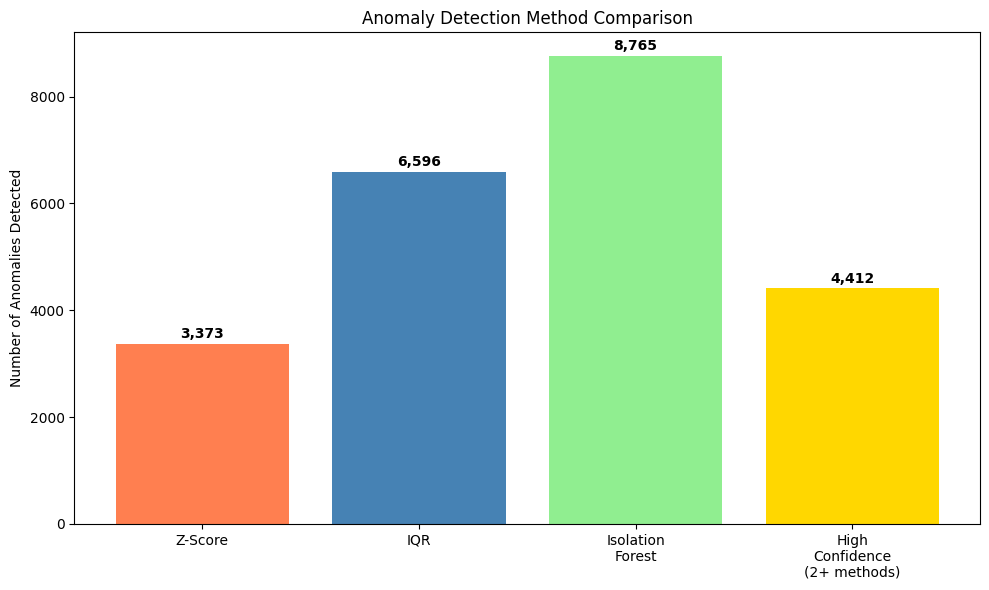

In [15]:
# Create consensus anomaly flag (detected by 2+ methods)
if 'iforest_anomaly' not in df.columns and 'isolation_forest_anomaly' in df.columns:
    df['iforest_anomaly'] = df['isolation_forest_anomaly']

df['anomaly_count'] = (df['zscore_anomaly'] + df['iqr_anomaly'] + df['iforest_anomaly'])
df['high_confidence_anomaly'] = (df['anomaly_count'] >= 2).astype(int)

print("Method Comparison Summary:")
print(f"Z-Score:           {df['zscore_anomaly'].sum():,} ({df['zscore_anomaly'].mean()*100:.2f}%)")
print(f"IQR:               {df['iqr_anomaly'].sum():,} ({df['iqr_anomaly'].mean()*100:.2f}%)")
print(f"Isolation Forest:  {df['iforest_anomaly'].sum():,} ({df['iforest_anomaly'].mean()*100:.2f}%)")
print(f"High Confidence:   {df['high_confidence_anomaly'].sum():,} ({df['high_confidence_anomaly'].mean()*100:.2f}%)")

# Visualize overlap
fig, ax = plt.subplots(figsize=(10, 6))
methods = ['Z-Score', 'IQR', 'Isolation\nForest', 'High\nConfidence\n(2+ methods)']
counts = [df['zscore_anomaly'].sum(), df['iqr_anomaly'].sum(), 
          df['iforest_anomaly'].sum(), df['high_confidence_anomaly'].sum()]

ax.bar(methods, counts, color=['coral', 'steelblue', 'lightgreen', 'gold'])
ax.set_ylabel('Number of Anomalies Detected')
ax.set_title('Anomaly Detection Method Comparison')
for i, v in enumerate(counts):
    ax.text(i, v + 100, f'{v:,}', ha='center', fontweight='bold')

plt.tight_layout()
save_and_show_plot(fig, 'anomaly_method_comparison.png')

## Export for Tableau Dashboard

Creating anomaly_results.csv with required columns.

In [16]:
# Determine primary anomaly method for each detection
def get_anomaly_method(row):
    methods = []
    if row['zscore_anomaly']: methods.append('Z-Score')
    if row['iqr_anomaly']: methods.append('IQR')
    if row['iforest_anomaly']: methods.append('Isolation Forest')
    return ', '.join(methods) if methods else 'None'

# Determine anomaly type
def get_anomaly_type(row):
    if row['high_confidence_anomaly']:
        return 'High Confidence'
    elif row['anomaly_count'] == 1:
        return 'Single Method'
    else:
        return 'Normal'

# Create export dataframe
anomaly_export = df[['timestamp', 'region', 'consumption_kwh']].copy()
anomaly_export['anomaly_flag'] = df['high_confidence_anomaly']  # Use high-confidence
anomaly_export['anomaly_type'] = df.apply(get_anomaly_type, axis=1)
anomaly_export['anomaly_method'] = df.apply(get_anomaly_method, axis=1)

print("Tableau Export Preview:")
print(f"Total rows: {len(anomaly_export):,}")
print(f"Anomalies flagged: {anomaly_export['anomaly_flag'].sum():,}")
print(f"\nSample:")
print(anomaly_export[anomaly_export['anomaly_flag'] == 1].head(10))

# Save
anomaly_export.to_csv(OUTPUT_DIR / 'anomaly_results.csv', index=False)
print(f"\n✓ Saved: output/anomaly_results.csv")

Tableau Export Preview:
Total rows: 438,240
Anomalies flagged: 4,412

Sample:
               timestamp            region  consumption_kwh  anomaly_flag  \
204  2015-01-10 12:00:00  Annapolis Valley           418.08             1   
209  2015-01-10 17:00:00  Annapolis Valley           508.01             1   
282  2015-01-13 18:00:00  Annapolis Valley           452.89             1   
283  2015-01-13 19:00:00  Annapolis Valley           377.87             1   
343  2015-01-16 07:00:00  Annapolis Valley           820.66             1   
490  2015-01-22 10:00:00  Annapolis Valley           676.04             1   
682  2015-01-30 10:00:00  Annapolis Valley          1081.36             1   
713  2015-01-31 17:00:00  Annapolis Valley           832.08             1   
931  2015-02-09 19:00:00  Annapolis Valley           797.86             1   
1018 2015-02-13 10:00:00  Annapolis Valley           489.16             1   

         anomaly_type                  anomaly_method  
204   High Confide